# It's Official — a quantitative teardown 🔬
### Turning-point leads vs a calendar-rotation null · an exact rotation test on 12 events · power · rules

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

**Real on the lead · None on the buy signal.** The companion to the
[notebook for the curious](01_for_the_curious.ipynb). Inference is by exact circular-shift
(rotation) randomisation throughout, because with n = 10–12 events nothing asymptotic applies.
§3.2 is the honest null for the lead (the estimator leans), §3.4 the buy-signal test, §3.5 the
power that bounds what "not significant" means.

> ⚠️ **Not investment advice.** Monthly tape: Fama-French market **total return** and T-bills
> (`arch`, fp `394be76d78ac`, as-of 2018-11-30). Daily tape: S&P 500 **price index**, no dividends
> (`skfolio` 1.8.1, fp `e223c581ae22`, as-of 2022-11-30). Numbers in prose mirror
> [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
GREEN, RED, BLUE, GREY, AMBER = "#2ea44f", "#c0392b", "#1f6feb", "#8b949e", "#dab617"

from nberclock import data, strategy as st
m = data.load_monthly()              # Fama-French monthly, TOTAL return, 1926-07 -> 2018-11
d = data.load_daily()                # S&P 500 daily PRICE index, 1990-01 -> 2022-11
tr = data.total_return_index(m)
xs = st.excess_index(m)
cyc, anns = data.cycles(), data.announcements()
print(f"monthly TR {m.index[0].date()} -> {m.index[-1].date()}  fp {data.fingerprint(m)}")
print(f"daily price {d.index[0].date()} -> {d.index[-1].date()}  fp {data.fingerprint(d)}")

def shade_recessions(ax, lo=None, hi=None):
    for _, c in cyc.iterrows():
        if (lo is None or c.trough >= lo) and (hi is None or c.peak <= hi):
            ax.axvspan(c.peak, c.trough, color=GREY, alpha=0.18, lw=0)

monthly TR 1926-07-31 -> 2018-11-30  fp 394be76d78ac
daily price 1990-01-02 -> 2022-11-30  fp e223c581ae22


## Verdict, up front (real tape)

| Axis | Stamp | Decisive numbers |
|---|---|---|
| **Signal** | Mixed — Real on the lead · None on the buy signal | market trough first in 14 of 15 uncensored cycles; vs shifted calendars 93% vs 71%, p = 0.032; buy signal: +3.1% vs +8.5% after random dates, rotation p = 0.82; MDE₈₀ = 17% |
| **Tradability** | Mirage | "equity 12 m after each announcement": net excess Sharpe 0.14 vs 0.52 (Δ −0.38, HAC t −3.17; shifted-date p = 0.76); daily Δ −0.27; "bills while officially in recession": Δ −0.09 / −0.07 |

> 💡 **In plain words.** The market does move first, but the press release is just a date.

## 1 · Hypotheses (fixed before the run)

- **H₁ (lead).** The market trough precedes the NBER trough in more cycles than (a) a coin and
  (b) the same estimator on month-shifted NBER calendars would produce.
- **H₂ (buy signal, primary).** Mean 12-month excess return after the 10 announcements on the
  monthly total-return tape exceeds every-circular-shift random dates, one-sided p < 0.05.
- **H₃ (tradability).** The rule "equity for 12 months after each announcement" beats
  buy-and-hold on net excess Sharpe on both tapes, with one execution lag and 10 bp one-way.

Window choices: market peak = max over [P − 24, P + 3] months; market trough = min over
[market peak, T + 12]. Horizon 12 months; 3/6/24 shown alongside.

## 2 · The calendar and the delay

In [2]:
anns.assign(reference=anns.reference.dt.strftime("%Y-%m"))

,kind,reference,date,lag_months,lag_days
0,peak,1980-01,1980-06-03,5,154
1,trough,1980-07,1981-07-08,12,372
2,peak,1981-07,1982-01-06,6,189
3,trough,1982-11,1983-07-08,8,249
4,peak,1990-07,1991-04-25,9,298
5,trough,1991-03,1992-12-22,21,662
6,peak,2001-03,2001-11-26,8,270
7,trough,2001-11,2003-07-17,20,623
8,peak,2007-12,2008-12-01,12,366
9,trough,2009-06,2010-09-20,15,476


## 3 · The teardown

### 3.1 Turning points, every cycle since 1926

In [3]:
ll = st.lead_lag_all(tr, d, cyc)
out = ll.copy()
for c in ("peak", "trough", "mkt_peak", "mkt_trough"):
    out[c] = out[c].dt.strftime("%Y-%m")
display(out[["peak", "trough", "mkt_peak", "mkt_trough", "lead_peak", "lead_trough",
             "dd_at_nber_peak", "max_dd", "censored", "tape"]])
s_all, s_bear = st.lead_summary(ll), st.lead_summary(ll, min_fall=0.10)
pd.DataFrame([s_all, s_bear], index=["all uncensored", "falls >= 10%"])[
    ["n", "trough_pos", "trough_neg", "trough_p", "trough_median", "peak_pos", "peak_p",
     "peak_median"]]

,peak,trough,mkt_peak,mkt_trough,lead_peak,lead_trough,dd_at_nber_peak,max_dd,censored,tape
0,1926-10,1927-11,1927-01,1927-01,-3,10,-0.057,0.000,True,FF total return
1,1929-08,1933-03,1929-08,1932-06,0,9,0.000,-0.837,False,FF total return
2,1937-05,1938-06,1937-02,1938-03,3,3,-0.083,-0.493,False,FF total return
3,1945-02,1945-10,1945-05,1945-07,-3,3,-0.052,-0.017,False,FF total return
4,1948-11,1949-10,1948-05,1948-11,6,11,-0.110,-0.110,False,FF total return
5,1953-07,1954-05,1952-12,1953-08,7,9,-0.028,-0.070,False,FF total return
6,1957-08,1958-04,1957-07,1957-12,1,4,-0.049,-0.149,False,FF total return
7,1960-04,1961-02,1959-12,1960-10,4,4,-0.079,-0.079,False,FF total return
8,1969-12,1970-11,1968-11,1970-06,13,5,-0.141,-0.336,False,FF total return
9,1973-11,1975-03,1972-12,1974-09,11,6,-0.202,-0.464,False,FF total return


,n,trough_pos,trough_neg,trough_p,trough_median,peak_pos,peak_p,peak_median
all uncensored,15,14,1,0.001,4.000,12,0.003,3.000
falls >= 10%,12,11,1,0.006,4.000,10,0.002,2.500


> 💡 **In plain words.** Against a coin flip the lead looks overwhelming (sign-test p ≈ 0.001).
> The next cell shows why a coin flip is the wrong yardstick.

### 3.2 The honest null for the lead: shift the whole NBER calendar

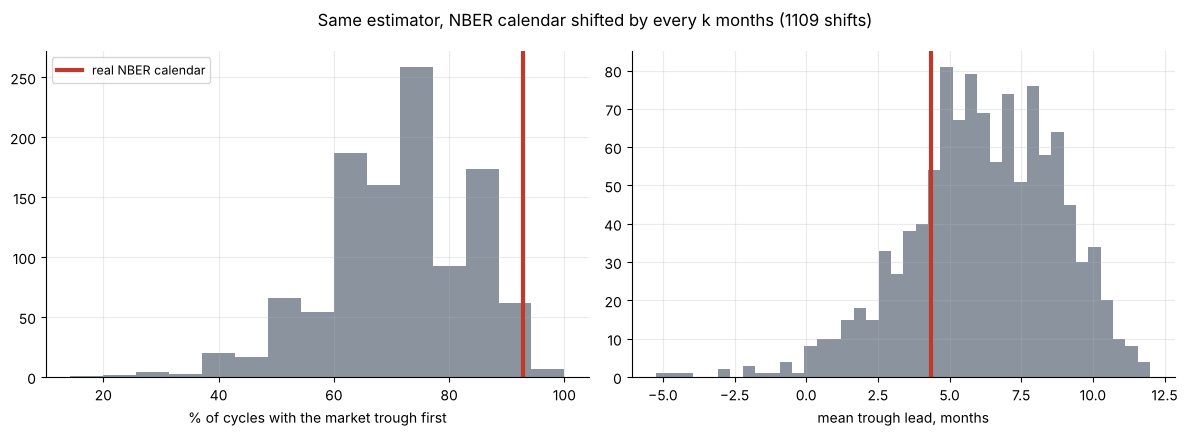

share first: 93% vs 71%  p = 0.032
mean lead:   4.4 vs 6.2 m  p = 0.78


In [4]:
lr = st.lead_rotation_test(tr, cyc)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].hist(lr["perm_share"] * 100, bins=15, color=GREY)
axes[0].axvline(lr["observed_share"] * 100, color=RED, lw=3, label="real NBER calendar")
axes[0].set_xlabel("% of cycles with the market trough first"); axes[0].legend(fontsize=9)
axes[1].hist(lr["perm_mean_lead"], bins=40, color=GREY)
axes[1].axvline(lr["observed_mean_lead"], color=RED, lw=3)
axes[1].set_xlabel("mean trough lead, months")
fig.suptitle(f"Same estimator, NBER calendar shifted by every k months ({lr['n_shifts']} shifts)")
plt.tight_layout(); plt.show()
print(f"share first: {lr['observed_share']:.0%} vs {lr['null_share_mean']:.0%}  p = {lr['p_share']:.3f}")
print(f"mean lead:   {lr['observed_mean_lead']:.1f} vs {lr['null_mean_lead']:.1f} m  p = {lr['p_mean_lead']:.2f}")

The estimator itself puts "the market first" 71% of the time on arbitrary dates —
on an upward-drifting index the lowest point after a high tends to come early. Against that
null the *direction* still clears (p = 0.032); the *size* (mean 4.4 m vs
6.2 m on shifted calendars, p = 0.78) does not. The synthetic null caught
this lean before the real tape was read with this test; the verdict's lead leg requires the
rotation p as well as the sign test.

> 💡 **In plain words.** The market reliably turns first; how *far* first is not a stable number.

In [5]:
rows = []
for slack in (0, 3, 6):
    for post in (6, 12, 18):
        g = st.lead_rotation_test(tr, cyc, peak_slack=slack, post_months=post)
        rows.append({"peak_slack": slack, "post_months": post, "share": g["observed_share"],
                     "null_share": g["null_share_mean"], "p_share": g["p_share"]})
pd.DataFrame(rows)

,peak_slack,post_months,share,null_share,p_share
0,0,6,1.000,0.797,0.034
1,0,12,0.929,0.762,0.061
2,0,18,0.929,0.739,0.040
3,3,6,1.000,0.755,0.012
4,3,12,0.929,0.714,0.032
5,3,18,0.929,0.689,0.023
6,6,6,0.929,0.669,0.007
7,6,12,0.857,0.628,0.023
8,6,18,0.857,0.604,0.014


Window robustness: the share test clears p < 0.05 for 8 of 9 window choices.

### 3.3 What was already done on announcement day

In [6]:
at_m = st.announcement_table(tr, anns)
at_d = st.announcement_table(d, anns, bars_per_month=21)
best = st.best_available(at_m, at_d)
best[["kind", "date", "lag_months", "already", "still_to_come", "share_done",
      "months_since_extreme", "fwd_3m", "fwd_12m", "fwd_24m", "tape"]]

,kind,date,lag_months,already,still_to_come,share_done,months_since_extreme,fwd_3m,fwd_12m,fwd_24m,tape
0,peak,1980-06-03,5,0.000,0.000,NaN,0.000,0.129,0.249,0.085,FF total return
1,trough,1981-07-08,12,0.471,NaN,NaN,21.000,-0.059,-0.148,0.405,FF total return
2,peak,1982-01-06,6,-0.088,-0.086,0.530,14.000,-0.016,0.296,0.505,FF total return
3,trough,1983-07-08,8,0.649,NaN,NaN,12.000,-0.008,-0.072,0.241,FF total return
4,peak,1991-04-25,9,0.000,-0.006,NaN,0.000,0.041,0.153,0.278,FF total return
5,trough,1992-12-22,21,0.630,NaN,NaN,26.000,0.041,0.111,0.109,FF total return
6,peak,2001-11-26,8,-0.261,-0.257,0.578,15.000,-0.017,-0.149,0.013,FF total return
7,trough,2003-07-17,20,0.252,NaN,NaN,10.000,0.074,0.134,0.323,FF total return
8,peak,2008-12-01,12,-0.400,-0.174,0.793,14.000,-0.100,0.284,0.508,FF total return
9,trough,2010-09-20,15,0.635,NaN,NaN,19.000,0.117,0.003,0.302,FF total return


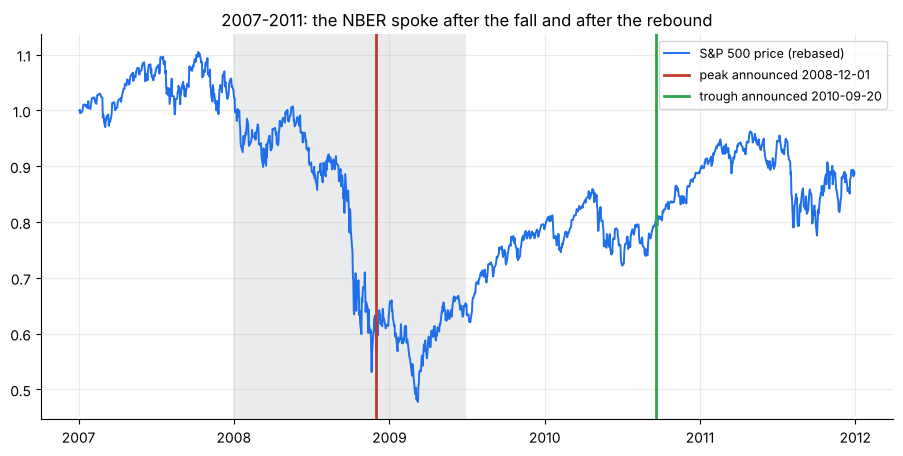

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
lvl = d / d.loc["2007-01-03"]
ax.plot(lvl.loc["2007":"2011"], color=BLUE, lw=1.4, label="S&P 500 price (rebased)")
for _, a in anns[(anns.date >= "2007-01-01") & (anns.date <= "2011-12-31")].iterrows():
    ax.axvline(a.date, color=RED if a.kind == "peak" else GREEN, lw=2,
               label=f"{a.kind} announced {a.date.date()}")
shade_recessions(ax, lo=pd.Timestamp("2007-01-01"), hi=pd.Timestamp("2011-12-31"))
ax.set_title("2007-2011: the NBER spoke after the fall and after the rebound")
ax.legend(fontsize=9); plt.show()

Median drawdown already realised at peak announcements: −6.7% (2 of 6 with no real
fall); median share of the cycle's fall already done 55%. At trough announcements:
median rebound already missed +63% (minimum +25%), the low a median 18
months earlier.

### 3.4 The buy-signal test — exact rotation

In [8]:
rows = []
for kinds, lbl in ((("peak", "trough"), "pooled"), (("peak",), "peak"), (("trough",), "trough")):
    for hm in (3, 6, 12, 24):
        for tape, lvl, bpm in (("monthly TR", xs, 1), ("daily price", d, 21)):
            r = st.rotation_test(lvl, st.event_positions(lvl.index, anns, kinds), hm * bpm)
            rows.append({"events": lbl, "h": hm, "tape": tape, "n": r["n_events"],
                         "obs": r["observed"], "random": r["null_mean"],
                         "p_up": r["p_one_sided"], "p_down": r["p_lower"]})
rt = pd.DataFrame(rows)
rt.pivot_table(index=["events", "h"], columns="tape", values=["obs", "random", "p_up"])

obs                   p_up                 random           
tape      daily price monthly TR daily price monthly TR daily price monthly TR
events h                                                                      
peak   3       -0.026     -0.007       0.903      0.746       0.022      0.020
       6        0.058      0.016       0.434      0.656       0.044      0.041
       12       0.139      0.100       0.329      0.430       0.095      0.085
       24       0.209      0.154       0.485      0.524       0.204      0.171
pooled 3        0.015      0.007       0.607      0.697       0.022      0.020
       6        0.078      0.028       0.156      0.646       0.044      0.041
       12       0.089      0.031       0.540      0.824       0.095      0.085
       24       0.199      0.158       0.503      0.511       0.204      0.171
trough 3        0.056      0.020       0.187      0.505       0.022      0.020
       6        0.098      0.041       0.175      0.495       0.044      0.041
       12       0.039     -0.039       0.713      0.927       0.095      0.085
       24       0.186      0.162       0.554      0.491       0.204      0.171

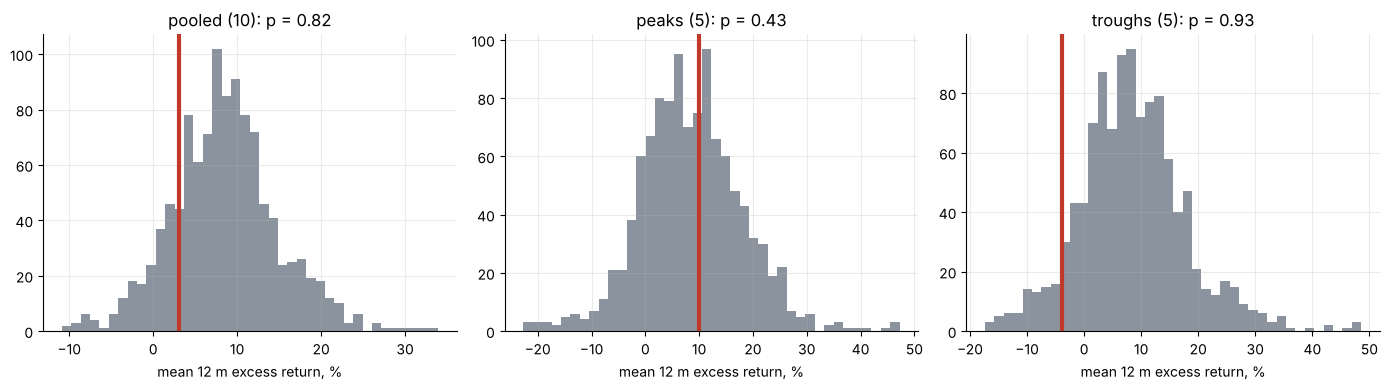

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, kinds, title in zip(axes, (("peak", "trough"), ("peak",), ("trough",)),
                            ("pooled (10)", "peaks (5)", "troughs (5)")):
    r = st.rotation_test(xs, st.event_positions(xs.index, anns, kinds), 12)
    ax.hist(r["perm"] * 100, bins=40, color=GREY)
    ax.axvline(r["observed"] * 100, color=RED, lw=3)
    ax.set_title(f"{title}: p = {r['p_one_sided']:.2f}")
    ax.set_xlabel("mean 12 m excess return, %")
plt.tight_layout(); plt.show()

Primary result: +3.1% after the announcements vs +8.5% after random dates,
**p = 0.82**; peaks alone p = 0.43, troughs alone p = 0.93; daily price tape
p = 0.54. The trough subgroup sits in the *lower* tail (p↓ ≈ 0.07) — one
tail of one subgroup among dozens of cells; recorded, not claimed.

> 💡 **In plain words.** The year after "it's official" looked like any other year — or a
> little worse.

### 3.5 Power on the synthetic world

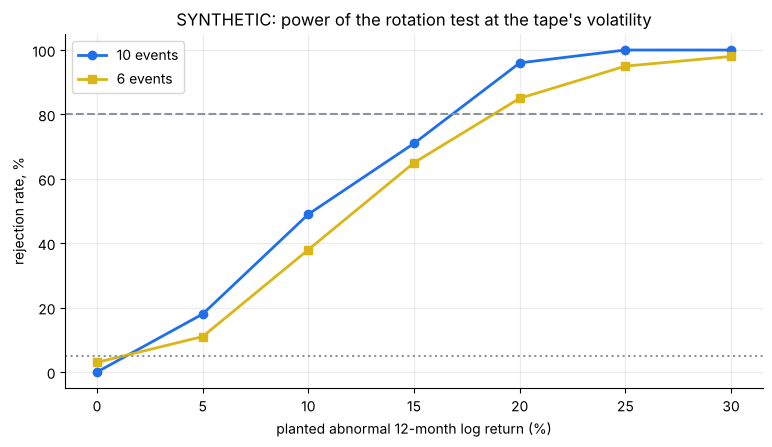

MDE80: 10 events 17%, 6 events 19%  (100 worlds per point here; results.md uses 200)


In [10]:
vol = float(m.mkt.std() * np.sqrt(12))
eff = (0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30)
pc10 = st.power_curve(effects=eff, n_sims=100, n_cycles=5, vol=vol)
pc6 = st.power_curve(effects=eff, n_sims=100, n_cycles=3, vol=vol, seed=2013)
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(pc10.index * 100, pc10.reject_rate * 100, "o-", color=BLUE, lw=2, label="10 events")
ax.plot(pc6.index * 100, pc6.reject_rate * 100, "s-", color=AMBER, lw=2, label="6 events")
ax.axhline(80, color=GREY, ls="--"); ax.axhline(5, color=GREY, ls=":")
ax.set_xlabel("planted abnormal 12-month log return (%)"); ax.set_ylabel("rejection rate, %")
ax.set_title("SYNTHETIC: power of the rotation test at the tape's volatility"); ax.legend()
plt.show()
print(f"MDE80: 10 events {st.minimum_detectable_effect(pc10):.0%}, "
      f"6 events {st.minimum_detectable_effect(pc6):.0%}  (100 worlds per point here; "
      f"results.md uses 200)")

At the tape's ~18% volatility, 10 events reach 80% power only at a planted ≈ 17% abnormal
12-month return (6 events: ≈ 19%). The size row (0% effect) sits near 5%: the rotation test
is honest; it is the sample that is small.

### 3.6 Positive control (synthetic) — fires on planted, quiet on null

In [11]:
rows = []
for s in (1.0, 0.0):
    w = data.synthetic_world(signal_strength=s, seed=1013)
    lvl = st.excess_index(w["returns"]); tri = (1 + w["returns"]["mkt"]).cumprod()
    r = st.rotation_test(lvl, st.event_positions(lvl.index, w["announcements"]), 12)
    lr_ = st.lead_rotation_test(tri, w["cycles"])
    rows.append({"signal_strength": s, "planted_lead": w["truth"]["lead_months"],
                 "lead_share_p": lr_["p_share"], "planted_premium": w["truth"]["announce_premium"],
                 "measured_excess": r["excess_vs_random"], "buy_p": r["p_one_sided"]})
pd.DataFrame(rows)

,signal_strength,planted_lead,lead_share_p,planted_premium,measured_excess,buy_p
0,1.000,5,0.014,0.150,0.214,0.001
1,0.000,0,0.354,0.000,0.009,0.344


## 4 · Could you trade it?

One execution lag (decided at bar *t*'s close, earns *t+1*); each switch trades 100% of NAV
at 10 bp one-way; Sharpe on excess-of-bills returns for every leg; active-return t is
Newey-West (12 lags monthly, 21 daily). Daily rows are price-only against 0% cash on both
sides.

In [12]:
mm = m[m.index >= "1980-01-01"]
dr = d.pct_change().dropna(); rf0 = pd.Series(0.0, index=dr.index)
sig_m = {"bills while officially in recession": st.signal_avoid(mm.index, anns),
         "equity 12 m after each announcement": st.signal_buy_after(mm.index, anns, 12),
         "equity 24 m after each peak announcement": st.signal_buy_after(mm.index, anns, 24, ("peak",))}
sig_d = {"bills while officially in recession": st.signal_avoid(dr.index, anns),
         "equity 12 m after each announcement": st.signal_buy_after(dr.index, anns, 252),
         "equity 24 m after each peak announcement": st.signal_buy_after(dr.index, anns, 504, ("peak",))}
cm = st.compare_rules(mm.mkt, mm.rf, sig_m, 10, 12, hac_lags=12)
cd = st.compare_rules(dr, rf0, sig_d, 10, 252, hac_lags=21)
display(cm[["exposure", "switches", "sharpe_gross", "sharpe_net", "sharpe_gain_net",
            "active_hac_t", "max_dd_net"]])
cd[["exposure", "switches", "sharpe_gross", "sharpe_net", "sharpe_gain_net", "active_hac_t",
    "max_dd_net"]]

,exposure,switches,sharpe_gross,sharpe_net,sharpe_gain_net,active_hac_t,max_dd_net
rule,,,,,,,
buy-and-hold,1.000,0,0.524,0.524,0.000,NaN,-0.504
bills while officially in recession,0.803,10,0.440,0.438,-0.086,-1.597,-0.410
equity 12 m after each announcement,0.244,18,0.146,0.140,-0.384,-3.175,-0.276
equity 24 m after each peak announcement,0.246,8,0.273,0.270,-0.254,-2.680,-0.276


,exposure,switches,sharpe_gross,sharpe_net,sharpe_gain_net,active_hac_t,max_dd_net
rule,,,,,,,
buy-and-hold,1.000,0,0.495,0.495,0.000,NaN,-0.568
bills while officially in recession,0.811,8,0.428,0.426,-0.069,-1.627,-0.519
equity 12 m after each announcement,0.243,16,0.235,0.230,-0.265,-2.891,-0.338
equity 24 m after each peak announcement,0.243,8,0.268,0.266,-0.229,-2.742,-0.355


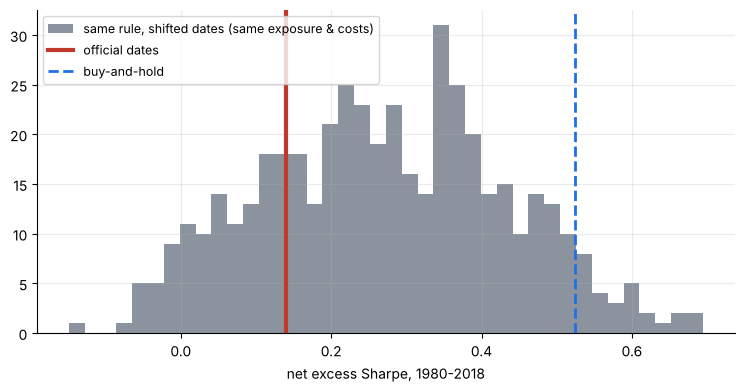

shifted-date p = 0.76


,sharpe_net,bh_sharpe,gain
cost_bps,,,
0,0.146,0.524,-0.378
5,0.143,0.524,-0.381
10,0.140,0.524,-0.384
25,0.131,0.524,-0.393
50,0.116,0.524,-0.408


In [13]:
key = "equity 12 m after each announcement"
rp = st.rule_rotation_test(mm.mkt, mm.rf, sig_m[key], 10, 12)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(rp["perm"], bins=40, color=GREY, label="same rule, shifted dates (same exposure & costs)")
ax.axvline(rp["observed_sharpe"], color=RED, lw=3, label="official dates")
ax.axvline(cm.loc["buy-and-hold", "sharpe_net"], color=BLUE, lw=2, ls="--", label="buy-and-hold")
ax.set_xlabel("net excess Sharpe, 1980-2018"); ax.legend(fontsize=9); plt.show()
print(f"shifted-date p = {rp['p_one_sided']:.2f}")
st.cost_sweep(mm.mkt, mm.rf, sig_m[key], costs=(0, 5, 10, 25, 50))

The buy-after rule's Sharpe (0.14) is below buy-and-hold (0.52) before costs,
so no break-even cost exists; and it is unremarkable against its own shifted-date versions
(p = 0.76) — timing adds nothing, the lower exposure (24% in equity) just
forfeits premium. The sceptic's rule (bills while officially in recession) costs
−0.09 of Sharpe monthly. Capacity is irrelevant: index switches a few times a decade.
**Mirage.**

> 💡 **In plain words.** Waiting for the referee loses whichever way you act on the whistle.

## 5 · Going further

- **More independent events.** Euro-area (CEPR) and other national dating committees would add
  announcements that are not the same twelve US dates; pooled, the MDE would roughly halve.
- **The trough curiosity** (below-random returns after "recovery" announcements) is worth a
  pre-registered test on that fresh sample.
- **Real-time recession signals** move earlier than the committee — 268-sahm-rule,
  626-unemployment-trend-timing and 881-jobless-claims-nowcast on this desk.
- **Price vs total-return dating.** Rerunning §3.1 on a price index (not shipped offline before
  1990) would move pre-1960 peaks earlier and troughs later.